# Clustering jerárquico
Recomendaciones de compras Amazon

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
data = pd.read_excel('Amazon.xlsx')
data.head()

,Unnamed: 0,Velocidad Entrega,Precio,Durabilidad,Imagen Producto,Valor Educativo,Servicio Retorno,Tamano Paquete,Calidad Producto,Numero Estrellas
0,Adam,205,3,345,235,24,23,26,21,17
1,Anna,9,15,315,33,25,4,42,215,28
2,Bernard,17,26,285,3,43,27,41,26,33
3,Edward,135,5,355,295,18,23,39,195,17
4,Emilia,3,45,48,39,34,46,225,34,43


In [2]:
import pandas as pd
from sklearn.preprocessing import normalize

# Separar columnas categoricas  y numéricas
numerical_cols = data.select_dtypes(include=['float64', 'int64']).columns
categorical_cols = data.select_dtypes(include=['object', 'category']).columns

# Normalizar solo columnas numéricas
data_numerical = data[numerical_cols]
data_numerical_scaled = normalize(data_numerical)

# Convertir de nuevo a DataFrame conservando los nombres de las columnas
data_numerical_scaled_df = pd.DataFrame(data_numerical_scaled, 
                                       columns=numerical_cols,
                                       index=data.index)

data_numerical_scaled_df 

,Velocidad Entrega,Precio,Durabilidad,Imagen Producto,Valor Educativo,Servicio Retorno,Tamano Paquete,Calidad Producto,Numero Estrellas
0,0.438263,0.006414,0.737565,0.502399,0.051309,0.049171,0.055585,0.044895,0.036344
1,0.023235,0.038725,0.813234,0.085196,0.064542,0.010327,0.108431,0.555065,0.072287
2,0.057235,0.087535,0.959520,0.010100,0.144770,0.090902,0.138036,0.087535,0.111102
3,0.258856,0.009587,0.680696,0.565649,0.034514,0.044101,0.074781,0.373904,0.032597
4,0.011975,0.179625,0.191600,0.155675,0.135717,0.183617,0.898127,0.135717,0.171642
...,...,...,...,...,...,...,...,...,...
95,0.045932,0.122484,0.489936,0.382763,0.107174,0.321521,0.643041,0.260279,0.015311
96,0.640241,0.052479,0.096561,0.050380,0.069272,0.058776,0.745198,0.054578,0.094462
97,0.005043,0.070602,0.131118,0.126075,0.121032,0.136161,0.211805,0.932952,0.115989
98,0.357707,0.025386,0.773109,0.078465,0.060003,0.066926,0.096927,0.496175,0.062310


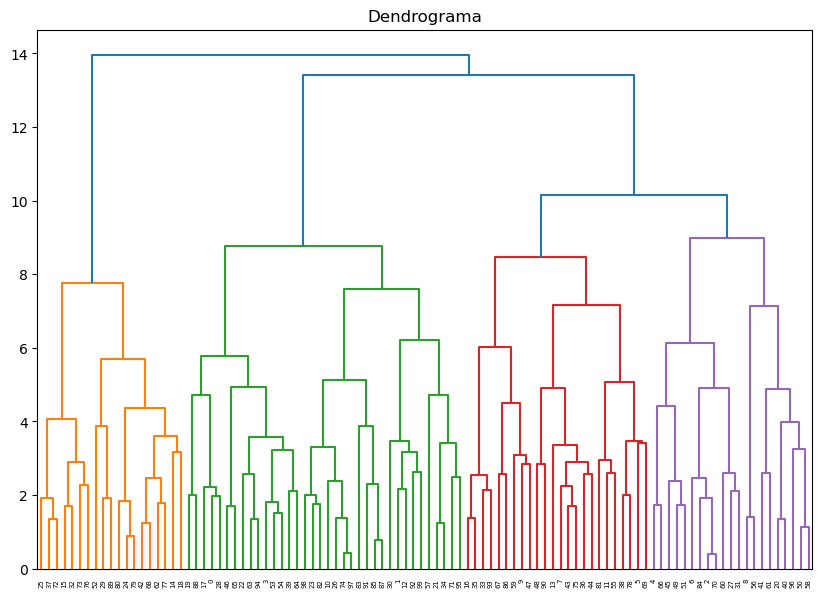

In [3]:
# Crear el algoritmo clustering jerárquico
import scipy.cluster.hierarchy as shc
from sklearn.preprocessing import StandardScaler

# Filtrar columnas categóricas y quedarse solo con númericas
numeric_columns = data.select_dtypes(include=['float64', 'int64']).columns
data_numeric = data[numeric_columns]

# Escalar datos numéricos
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data_numeric)

# Crear el dendograma
plt.figure(figsize=(10,7))
plt.title('Dendrograma')  # Fixed typo in 'Dentograma'
dend = shc.dendrogram(shc.linkage(data_scaled, method='ward'))
plt.show()

In [4]:
# Verificar los colores únicos
colores_unicos = set(dend['color_list'])
num_clusters_optimo = len(colores_unicos)-1
num_clusters_optimo

4

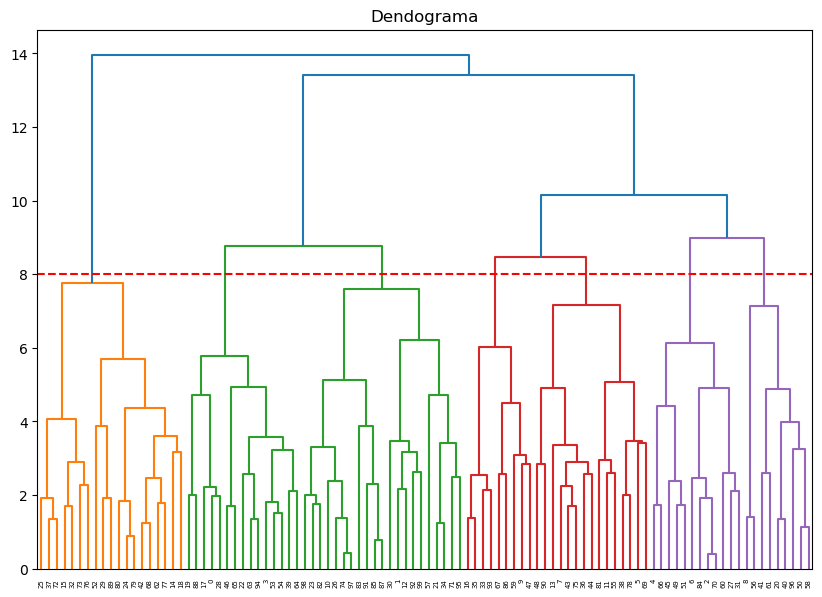

In [5]:
plt.figure(figsize=(10,7))
plt.title("Dendograma")
dend = shc.dendrogram(shc.linkage(data_scaled, method='ward'))
plt.axhline(y=8, color='r', linestyle ='--')

In [6]:
# Análisis gráfio con PCA
campos = data_scaled
from sklearn import decomposition
pca = decomposition.PCA(n_components = 2)
pca.fit(campos)
campos = pca.transform(campos)
campos

array([[ 1.94333789e-01, -1.58560889e+00],
       [ 1.50353542e-01, -1.20841395e+00],
       [ 3.37626029e-01,  5.69333744e-01],
       [ 1.30811356e-01, -2.00000504e+00],
       [-4.41908254e-01,  2.30292971e+00],
       [-1.70228918e+00,  8.21047543e-01],
       [ 8.89555116e-02,  3.36770020e-01],
       [-1.72653845e-01,  4.17650303e-01],
       [ 2.13695516e+00, -2.51748071e-01],
       [-3.23436960e-01,  2.98290883e+00],
       [-1.95535814e+00, -1.14073157e+00],
       [-7.39284892e-01,  3.43488573e-02],
       [-6.93652154e-01, -1.10552364e+00],
       [-5.01348032e-01,  1.00799875e+00],
       [ 1.45601872e+00, -1.64579299e+00],
       [ 9.73812495e-01, -1.41726461e+00],
       [-2.06783848e-01,  7.21164790e-01],
       [ 9.50935837e-01, -4.30516626e-01],
       [ 2.76133119e+00, -8.02030987e-01],
       [-9.06912995e-01, -2.54936927e+00],
       [-2.40925651e-01,  4.50528719e-01],
       [-1.50155465e+00, -2.55918854e+00],
       [-7.04412759e-01, -1.65883547e+00],
       [-6.

In [7]:
# Agregar una columna que permita etiquetar ¿qué elemento corresponde a qué grupo?
from sklearn.cluster import AgglomerativeClustering
cluster = AgglomerativeClustering(n_clusters=3, metric='euclidean', linkage='ward')
grupos = cluster.fit_predict(data_scaled)
grupos

array([2, 2, 0, 2, 0, 0, 0, 0, 0, 0, 2, 0, 2, 0, 1, 1, 0, 2, 1, 2, 0, 2,
       2, 2, 1, 1, 2, 0, 2, 1, 2, 0, 1, 0, 2, 0, 0, 1, 0, 2, 0, 0, 1, 0,
       0, 0, 2, 0, 0, 0, 0, 0, 1, 2, 2, 0, 0, 2, 0, 0, 0, 0, 1, 2, 2, 2,
       0, 0, 1, 0, 0, 2, 1, 1, 2, 0, 1, 1, 0, 1, 1, 0, 2, 2, 0, 2, 0, 2,
       2, 1, 0, 2, 2, 0, 2, 2, 0, 2, 2, 2])

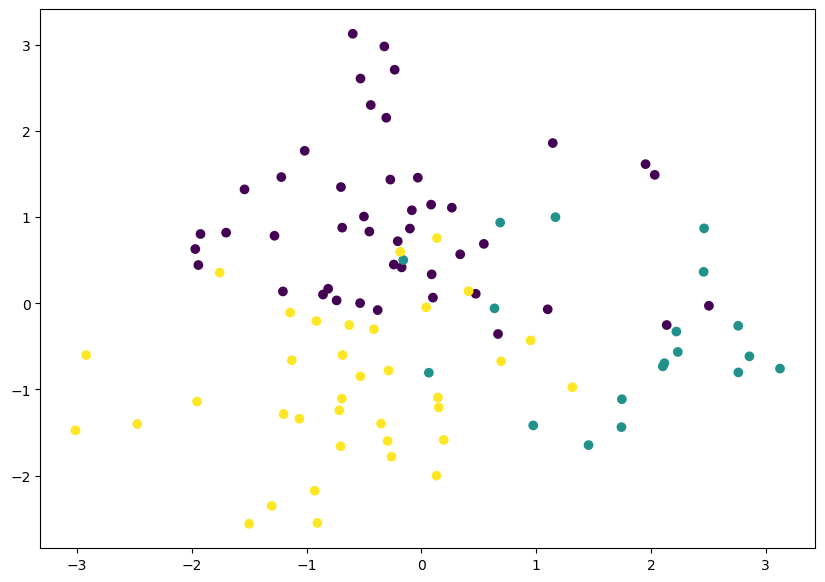

In [8]:
plt.figure(figsize = (10,7))
plt.scatter(campos[:,0], campos[:,1], c=cluster.labels_)

In [9]:
dataframe = pd.DataFrame(grupos, columns=['grupos'])
dataframe

,grupos
0,2
1,2
2,0
3,2
4,0
...,...
95,2
96,0
97,2
98,2


In [10]:
# Concatenar datafreme's
dataframe2 = pd.concat([data, dataframe], axis=1, join = 'inner')
dataframe2

,Unnamed: 0,Velocidad Entrega,Precio,Durabilidad,Imagen Producto,Valor Educativo,Servicio Retorno,Tamano Paquete,Calidad Producto,Numero Estrellas,grupos
0,Adam,205,3,345,235,24,23,26,21,17,2
1,Anna,9,15,315,33,25,4,42,215,28,2
2,Bernard,17,26,285,3,43,27,41,26,33,0
3,Edward,135,5,355,295,18,23,39,195,17,2
4,Emilia,3,45,48,39,34,46,225,34,43,0
...,...,...,...,...,...,...,...,...,...,...,...
95,Teofan,3,8,32,25,7,21,42,17,1,2
96,Teofil,305,25,46,24,33,28,355,26,45,0
97,Teofila,1,14,26,25,24,27,42,185,23,2
98,Teon,155,11,335,34,26,29,42,215,27,2


In [11]:
# Usar la primera columna cono índice
dataframe2 = dataframe2.set_index(dataframe2.columns[0])
dataframe2

,Velocidad Entrega,Precio,Durabilidad,Imagen Producto,Valor Educativo,Servicio Retorno,Tamano Paquete,Calidad Producto,Numero Estrellas,grupos
Unnamed: 0,,,,,,,,,,
Adam,205,3,345,235,24,23,26,21,17,2
Anna,9,15,315,33,25,4,42,215,28,2
Bernard,17,26,285,3,43,27,41,26,33,0
Edward,135,5,355,295,18,23,39,195,17,2
Emilia,3,45,48,39,34,46,225,34,43,0
...,...,...,...,...,...,...,...,...,...,...
Teofan,3,8,32,25,7,21,42,17,1,2
Teofil,305,25,46,24,33,28,355,26,45,0
Teofila,1,14,26,25,24,27,42,185,23,2


In [12]:
# Filtrar por grupos 0
rows_group_0 = dataframe2[dataframe2['grupos'] == 0]
print(rows_group_0)

             Velocidad Entrega  Precio  Durabilidad  Imagen Producto  \
Unnamed: 0                                                             
Bernard                     17      26          285                3   
Emilia                       3      45           48               39   
Fabian                      95     165          395               24   
Philip                      23      12          475               33   
Frank                       65      21           31              255   
Xavier                     275       8           47              235   
Gabriel                      2     175          325                3   
Henry                      195      11          455               23   
Isabelle                   185      75           43              285   
Eugene                      16     205          285              255   
Evdokia                    165      45           43                2   
Florence                    26      65          485             

In [13]:
# Filtrar por grupos 1
rows_group_1 = dataframe2[dataframe2['grupos'] == 1]
print(rows_group_1)

            Velocidad Entrega  Precio  Durabilidad  Imagen Producto  \
Unnamed: 0                                                            
Isidore                   235      65          495              335   
Joseph                     17       1          485              235   
Eunice                    265       7          485              305   
Flavia                    255       7          435               24   
Flora                      23     105          395               29   
Helen                     205     185          295              275   
Lourdes                    26       1          465              295   
Jervis                      2      45          455               27   
Judith                    245     115          465              225   
Louise                    225     205          315              295   
Markian                   205      55          465              275   
Maura                     265      85          425              185   
Method

In [14]:
# Filtrar por grupos 2
rows_group_2 = dataframe2[dataframe2['grupos'] == 2]
print(rows_group_2)

            Velocidad Entrega  Precio  Durabilidad  Imagen Producto  \
Unnamed: 0                                                            
Adam                      205       3          345              235   
Anna                        9      15          315               33   
Edward                    135       5          355              295   
Marisol                    12       8           44               24   
Irene                      14       7          405               19   
Eugenia                   245       9          385              215   
Eva                       235      65          495              335   
Fedir                      17       2          415              125   
Felix                      15       2          455              355   
Fialka                     12      75          335               24   
Florent                    12      75           33               24   
Hannah                    175      14          495              175   
Herman